# Organización de datos
---
## <center> Trabajo Práctico 1

### <center> Ejercicio 1 - Análisis Exploratorio de Datos

#### Grupo 05
| Integrante | Padrón |
| :--- | :---: |
| Javier Zardain | 102521 |
| Bruno Pezman | 110457  |
| Malena Sein | 112295 |
| Candela Piccin | 109760 |
| Alexis Maximiliano Torres Vargas | 111449 |


---

**Dataset:** Yellow Cab NYC — Viajes de abril, mayo y junio de 2025  

**Fuente:** NYC Taxi and Limousine Commission (TLC)

**Bibliografía:**
* Data dictionary: https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf
* Flex Fare report: https://www.nyc.gov/assets/tlc/downloads/pdf/flex_fare_pilot_report_06_2019.pdf
* Taxi fare: https://www.nyc.gov/site/tlc/passengers/taxi-fare.page ; https://www.mta.info/fares-tolls/tolls/congestion-relief-zone/taxi-fhv-tolls



## 1. Importación de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
from IPython.display import display
import gc
gc.collect()

0

## 2. Carga del dataset


In [ ]:
!gdown 1mTkleDBGx7c64dbxsQ_JqfPG_SlhrOSF -O yellow_tripdata_2025-04.parquet
!gdown 1e804Ta_-SIYxgBVbBC_rprM8jZUQvf7Q -O yellow_tripdata_2025-05.parquet
!gdown 1Ov0sHYeDY67CIXF2MowLLiFrjbtV3PA8 -O yellow_tripdata_2025-06.parquet
!gdown 1lWI4HmgszWKUS3mXA0rL9Uujz3und_p5 -O taxi_zone_lookup.csv
!gdown 1EmfjWgllcMRgGE25-6tzYBMOU9Qn7Z3p -O taxi_zones.zip

Downloading...
From: https://drive.google.com/uc?id=1mTkleDBGx7c64dbxsQ_JqfPG_SlhrOSF
To: /content/yellow_tripdata_2025-04.parquet
100% 67.4M/67.4M [00:00<00:00, 173MB/s]
Downloading...
From: https://drive.google.com/uc?id=1e804Ta_-SIYxgBVbBC_rprM8jZUQvf7Q
To: /content/yellow_tripdata_2025-05.parquet
100% 77.8M/77.8M [00:00<00:00, 90.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Ov0sHYeDY67CIXF2MowLLiFrjbtV3PA8
To: /content/yellow_tripdata_2025-06.parquet
100% 73.5M/73.5M [00:00<00:00, 84.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1lWI4HmgszWKUS3mXA0rL9Uujz3und_p5
To: /content/taxi_zone_lookup.csv
100% 12.3k/12.3k [00:00<00:00, 27.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1EmfjWgllcMRgGE25-6tzYBMOU9Qn7Z3p
To: /content/taxi_zones.zip
100% 1.03M/1.03M [00:00<00:00, 78.9MB/s]


In [ ]:
dfs = [
  pd.read_parquet('/content/yellow_tripdata_2025-04.parquet'),
  pd.read_parquet('/content/yellow_tripdata_2025-05.parquet'),
  pd.read_parquet('/content/yellow_tripdata_2025-06.parquet')
]

df = pd.concat(dfs, ignore_index=True)

del dfs # limpio la lista que ya no uso para liberar memoria

## 3. Exploración inicial del dataset

En esta sección buscamos conocer **cómo se organizan los datos**: tipos de datos, tamaño , presencia de nulos y distribución de la información.


*   Filas y columnas.
*   Tipos y cantidad de entradas en cada columna.
*   Visualización de una muestra.



In [ ]:
print("Cantidad de columnas: ", df.shape[1])
print("Cantidad de filas:", df.shape[0])

Cantidad de columnas:  20
Cantidad de filas: 12885358


In [ ]:
df.info(show_counts=True) # vemos el nombre, dtype de cada columna y si hay nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12885358 entries, 0 to 12885357
Data columns (total 20 columns):
 #   Column                 Non-Null Count     Dtype         
---  ------                 --------------     -----         
 0   VendorID               12885358 non-null  int32         
 1   tpep_pickup_datetime   12885358 non-null  datetime64[us]
 2   tpep_dropoff_datetime  12885358 non-null  datetime64[us]
 3   passenger_count        9730506 non-null   float64       
 4   trip_distance          12885358 non-null  float64       
 5   RatecodeID             9730506 non-null   float64       
 6   store_and_fwd_flag     9730506 non-null   object        
 7   PULocationID           12885358 non-null  int32         
 8   DOLocationID           12885358 non-null  int32         
 9   payment_type           12885358 non-null  int64         
 10  fare_amount            12885358 non-null  float64       
 11  extra                  12885358 non-null  float64       
 12  mta_tax     

Vemos que no todas las columnas tiene la misma cantidad de datos que la cantidad total de filas en el dataset (`12885358`), es decir que algunas columnas tienen valores nulos

In [ ]:
df.sample(3)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
3202011,2,2025-04-30 20:05:19,2025-04-30 20:21:35,1.0,2.37,1.0,N,162,249,1,16.30,1.0,0.5,4.41,0.00,1.0,26.46,2.5,0.0,0.75
12252753,2,2025-06-15 01:25:20,2025-06-15 01:54:56,NaN,8.39,NaN,None,112,166,0,43.15,0.0,0.5,0.00,0.00,1.0,47.15,NaN,NaN,0.00
8185947,2,2025-05-21 17:32:28,2025-05-21 19:00:19,NaN,0.00,NaN,None,230,132,0,98.01,0.0,0.5,1.00,6.94,1.0,110.70,NaN,NaN,0.75


## 4. Clasificación de variables

Basándonos en el **Data Dictionary** del TLC y la inspección del dataset, clasificamos las variables en cualitativas y cuantitativas.

In [ ]:
var_cualitativa = ["VendorID",
                   "RatecodeID",
                   "store_and_fwd_flag",
                   "PULocationID",
                   "DOLocationID",
                   "payment_type"
                   ]
var_cuantitativa = ["tpep_pickup_datetime",
                    "tpep_dropoff_datetime",
                    "passenger_count",
                    "trip_distance",
                    "fare_amount",
                    "extra",
                    "mta_tax",
                    "tip_amount",
                    "tolls_amount",
                    "improvement_surcharge",
                    "total_amount",
                    "congestion_surcharge",
                    "Airport_fee",
                    "cbd_congestion_fee"
                    ]
print("Variables cualitativas:", var_cualitativa)
print("Variables cuantitativas:", var_cuantitativa)


Variables cualitativas: ['VendorID', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type']
Variables cuantitativas: ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']




Basándonos en la descripción y los tipos de datos, podemos clasificar las variables de la siguiente forma:

### Variables Cualitativas (Categóricas):
*   ``VendorID``: Código del proveedor de la compañía.
*   ``RatecodeID``: Código de la tarifa aplicada al viaje.
*   ``store_and_fwd_flag``: Indicador si el vehículo fue almacenado antes de enviarse.
*   ``PULocationID``: ID de la zona de recogida.
*   ``DOLocationID``: ID de la zona de destino.
*   ``payment_type``: Tipo de pago realizado por el pasajero.

### Variables Cuantitativas (Numéricas):
*   ``tpep_pickup_datetime``: Fecha y hora de inicio del viaje.
*   ``tpep_dropoff_datetime``: Fecha y hora de fin del viaje.
*   ``passenger_count``: Número de pasajeros.
*   ``trip_distance``: Distancia recorrida en millas.
*   ``fare_amount``: Tarifa base del viaje.
*   ``extra``: Cargos extra y recargos.
*   ``mta_tax``: Impuesto.
*   ``tip_amount``: Cantidad de propina.
*   ``tolls_amount``: Cantidad total de peajes.
*   ``improvement_surcharge``: Recargo por mejora.
*   ``total_amount``: Monto total cobrado.
*   ``congestion_surcharge``: Recargo por congestión.
*   ``Airport_fee``: Tarifa de aeropuerto.
*   ``cbd_congestion_fee``: Tarifa de congestión.

### 4.1 Medidas de resumen — Variables cuantitativas

La función `describe()` nos provee estadísticos clave: media, desvío estándar, mínimo, cuartiles y máximo. Esto nos permite identificar rápidamente distribuciones asimétricas y posibles outliers.

In [ ]:
df[var_cuantitativa].describe().T # Cambio las filas por las columnas para mejor visualización

,count,mean,min,25%,50%,75%,max,std
tpep_pickup_datetime,12885358,2025-05-17 06:43:35.693359,2009-01-01 00:20:39,2025-04-25 16:25:13,2025-05-17 02:06:32,2025-06-08 11:37:55,2025-06-30 23:59:59,NaN
tpep_dropoff_datetime,12885358,2025-05-17 07:00:56.561819,2009-01-01 00:20:49,2025-04-25 16:46:34.250000,2025-05-17 02:20:20.500000,2025-06-08 11:55:10.750000,2025-07-01 22:36:42,NaN
passenger_count,9730506.0,1.300557,0.0,1.0,1.0,1.0,9.0,0.737402
trip_distance,12885358.0,7.391721,0.0,1.05,1.87,3.7,386088.43,670.054815
fare_amount,12885358.0,18.444917,-1777.5,8.6,14.12,22.6,325478.05,92.734544
extra,12885358.0,1.188643,-17.39,0.0,0.0,2.5,133.6,1.850769
mta_tax,12885358.0,0.477048,-21.74,0.5,0.5,0.5,22.14,0.14052
tip_amount,12885358.0,2.860194,-90.44,0.0,2.0,3.99,960.94,3.99799
tolls_amount,12885358.0,0.503771,-148.17,0.0,0.0,0.0,716.05,2.13282
improvement_surcharge,12885358.0,0.954671,-1.0,1.0,1.0,1.0,1.0,0.279334


**Observaciones iniciales:**
- `trip_distance` tiene un mínimo de 0 y valores máximos extremadamente altos → indica outliers.
- `fare_amount` y `total_amount` presentan valores negativos → registros erróneos a limpiar.
- `passenger_count` tiene valor máximo inusualmente alto → posible error de carga.
- El percentil 75 de `tip_amount` es relativamente bajo vs. la media → distribución muy sesgada a la derecha.

### 4.2 Valores posibles - Variables cualitativas

In [ ]:
valores_unicos = [df[i].unique() for i in var_cualitativa]
cantidades = [df[i].nunique() for i in var_cualitativa]

tabla_cualitativas = pd.DataFrame({
    "Variable": var_cualitativa,
    "Valores unicos": valores_unicos,
    "Cantidad": cantidades
})
display(tabla_cualitativas)

,Variable,Valores unicos,Cantidad
0,VendorID,"[1, 2, 7, 6]",4
1,RatecodeID,"[1.0, 2.0, 5.0, 99.0, 4.0, 3.0, 6.0, nan]",7
2,store_and_fwd_flag,"[N, Y, None]",2
3,PULocationID,"[138, 132, 79, 161, 233, 239, 144, 142, 162, 6...",262
4,DOLocationID,"[230, 92, 130, 4, 229, 164, 140, 116, 238, 162...",263
5,payment_type,"[1, 2, 4, 3, 0, 5]",6


In [ ]:
df["mta_tax"].unique()

array([  0.5 ,  -0.5 ,   0.  ,   4.  ,   4.75,   5.  ,  10.5 ,   1.  ,
        22.14,   1.03,   0.8 ,   3.75,   3.5 ,   3.25,   3.  ,  -4.49,
        -5.42,  -4.99, -10.4 ,  -9.08,  -7.99,  -2.55,  -1.44,  -1.23,
        -2.25,  -1.66,  -7.81,  -4.97,  -2.41, -10.32,  -3.91,  -2.1 ,
        -4.78,  -6.44,  -3.65,  -3.27,  -5.34,  -5.61,  -4.3 ,  -3.01,
        -8.82,  -3.14,  -5.23,  -4.83,  -3.63,  -6.15,  -4.24,  -2.49,
        -5.92,  -3.47,  -3.98,  -5.93,  -4.09,  -6.38,  -1.3 ,  -4.25,
        -4.4 ,  -2.44, -21.74,  -0.66,  -4.7 ,  -4.76,  -3.39,   0.3 ,
        -5.75,  -4.57,  -2.73, -10.49,  -2.97])

In [ ]:
df["improvement_surcharge"].unique()

array([ 1. , -1. ,  0. ,  0.3])

In [ ]:
df["store_and_fwd_flag"].unique()

array(['N', 'Y', None], dtype=object)

Podemos ver la correlación de variables, representadas en un `heatmap`

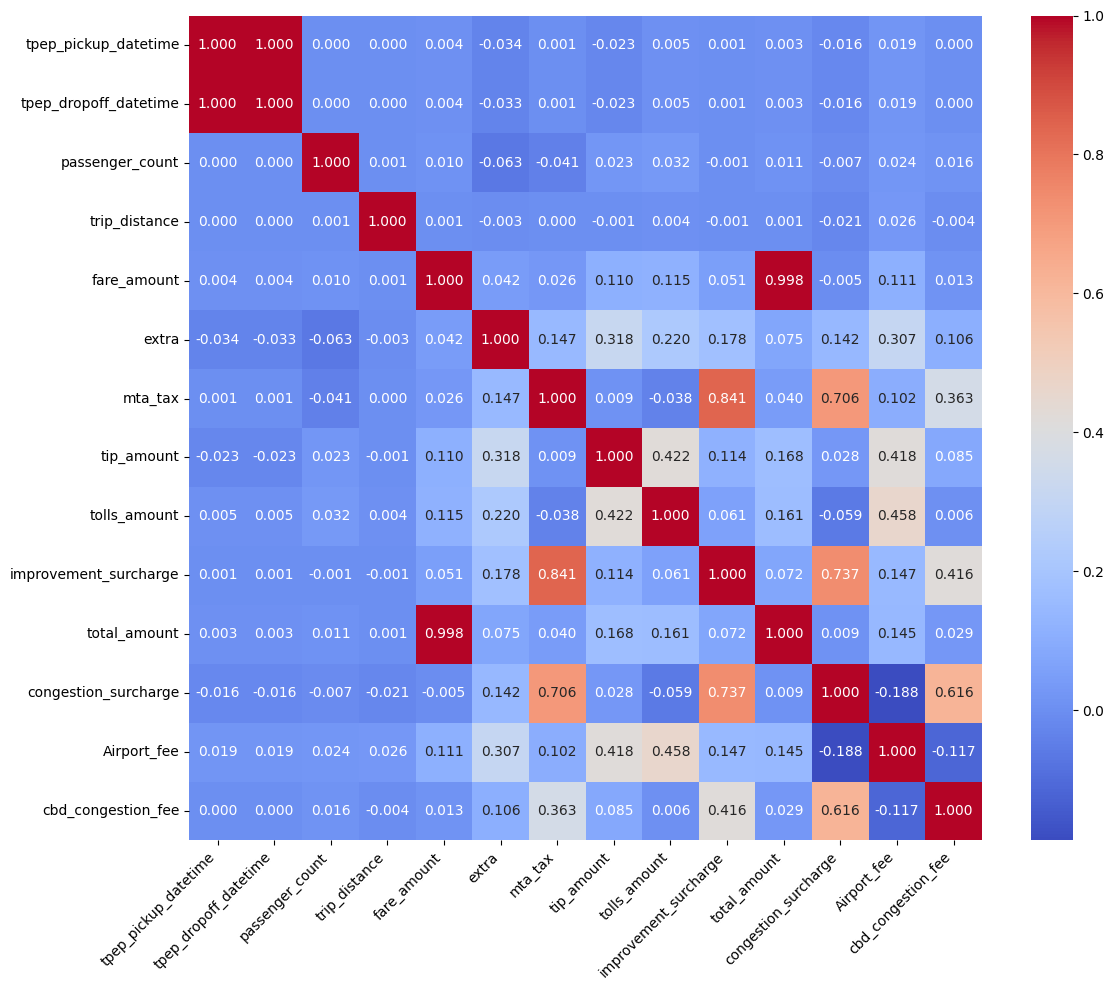

In [ ]:
# esto para que el heapmap que muestra correlaciones se vea bien
plt.figure(figsize=(12, 10))
sns.heatmap(
    df[var_cuantitativa].corr(),
    annot=True,
    fmt=".3f",
    cmap="coolwarm"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### 4.3 Gráficos de variables relevantes

Para entender la forma real de los datos antes de analizarlos elegimos graficar variables que nos parecieron relevantes: `trip_distance`, `total_amount`, `payment_type` y `passenger_count`

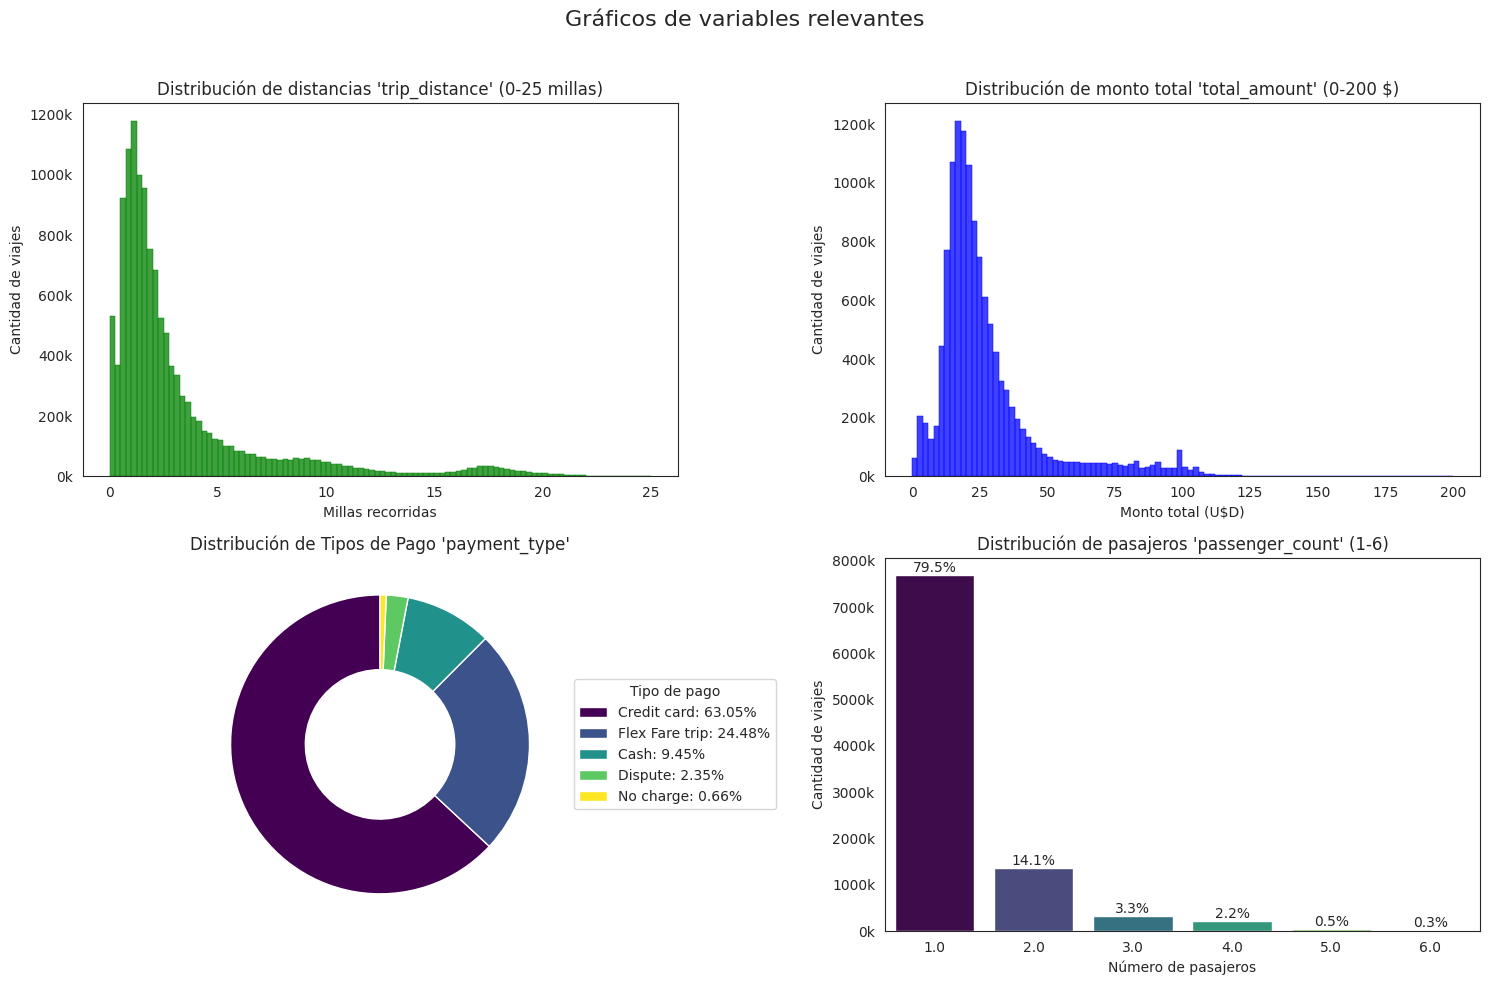

In [ ]:
sns.set_style("white")

# Grilla para ubicar los graficos
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Gráficos de variables relevantes", fontsize=16)

# Histograma para trip_distance
sample = df[(df["trip_distance"] >= 0) & (df["trip_distance"] <= 25)]["trip_distance"]

sns.histplot(
    sample,
    bins=100,
    kde=False,
    color="green",
    edgecolor="green",
    ax=axs[0, 0]
)

axs[0, 0].set_title("Distribución de distancias 'trip_distance' (0-25 millas)")
axs[0, 0].set_xlabel("Millas recorridas")
axs[0, 0].set_ylabel("Cantidad de viajes")
axs[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))

# Histograma total_amount
sample_total_amount = df[(df["total_amount"] >= 0) & (df["total_amount"] <= 200)]["total_amount"]

sns.histplot(
    sample_total_amount,
    bins=100,
    kde=False,
    color="blue",
    edgecolor="blue",
    ax=axs[0, 1]
)

axs[0, 1].set_title("Distribución de monto total 'total_amount' (0-200 $)")
axs[0, 1].set_xlabel("Monto total (U$D)")
axs[0, 1].set_ylabel("Cantidad de viajes")
axs[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))

# Dona para payment_type
payment_type_map = {
    0: 'Flex Fare trip',
    1: 'Credit card',
    2: 'Cash',
    3: 'No charge',
    4: 'Dispute',
    5: 'Unknown',
    6: 'Voided trip'
}

payment_counts = df['payment_type'].value_counts()
payment_counts = payment_counts[payment_counts > 5]

nombres_payment = [payment_type_map.get(i, 'Unknown') for i in payment_counts.index]
valores_porcentajes_payment = (payment_counts.values / payment_counts.sum()) * 100

colors = plt.cm.viridis(np.linspace(0, 1, len(nombres_payment)))

wedges, _ = axs[1, 0].pie(valores_porcentajes_payment, colors=colors, startangle=90, wedgeprops=dict(width=0.5))

leyenda = [f"{nombre}: {valor:.2f}%" for nombre, valor in zip(nombres_payment, valores_porcentajes_payment)]
axs[1, 0].legend(wedges, leyenda, title="Tipo de pago", loc="center left", bbox_to_anchor=(1, 0.5))

axs[1, 0].set_title("Distribución de Tipos de Pago 'payment_type'")

# Bar chart passenger_count
passenger_counts = df['passenger_count'].value_counts().sort_index()
passenger_counts = passenger_counts[(passenger_counts.index > 0) & (passenger_counts.index <= 6)]

ax = sns.barplot(
    x=passenger_counts.index,
    y=passenger_counts.values,
    hue=passenger_counts.index,
    palette='viridis',
    legend=False,
    ax=axs[1, 1]
)

total = passenger_counts.sum()
for i, v in enumerate(passenger_counts):
    axs[1, 1].text(i, v, f'{v/total:.1%}', ha='center', va='bottom')

axs[1, 1].set_title("Distribución de pasajeros 'passenger_count' (1-6)")
axs[1, 1].set_xlabel("Número de pasajeros")
axs[1, 1].set_ylabel("Cantidad de viajes")
axs[1, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))

# ---------------------------------------------------------
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 5. Revisión de datos faltantes

Analizamos que columnas tienen valores nulos

In [ ]:
nulos = (df.isna().mean() * 100).sort_values(ascending=False)
nulos_df = nulos[nulos > 0].reset_index()
nulos.columns = ['Columna', '% Nulos']
display(nulos_df)

,index,0
0,passenger_count,24.484007
1,congestion_surcharge,24.484007
2,store_and_fwd_flag,24.484007
3,RatecodeID,24.484007
4,Airport_fee,24.484007


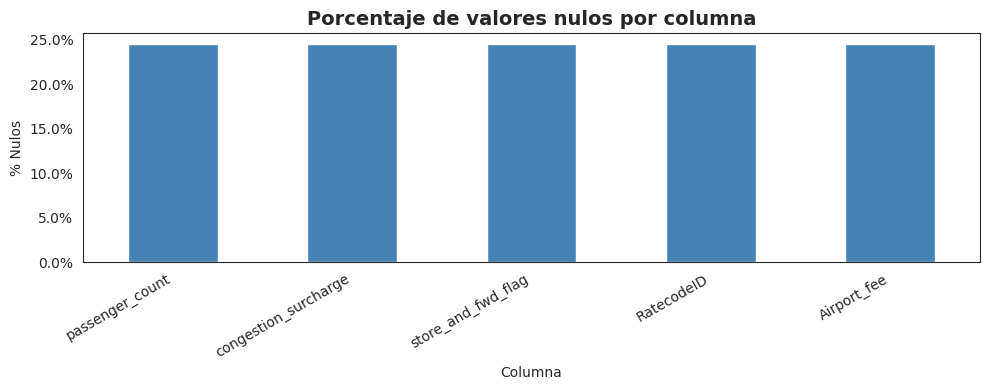

In [ ]:
# Visualización del porcentaje de nulos
cols_con_nulos = nulos[nulos > 0]
fig, ax = plt.subplots(figsize=(10, 4))
cols_con_nulos.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Porcentaje de valores nulos por columna', fontsize=14, fontweight='bold')
ax.set_xlabel('Columna')
ax.set_ylabel('% Nulos')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Se observa que cinco variables presentan exactamente el mismo porcentaje de valores faltantes (~24.48%): ``passenger_count``, ``RatecodeID``, ``store_and_fwd_flag``, ``congestion_surcharge`` y ``Airport_fee``.

Verificamos si los registros con nulos en estas columnas son siempre los mismos, es decir, si la ausencia de datos está correlacionada entre ellas.

In [ ]:
cols_verificar = ["RatecodeID", "store_and_fwd_flag", "Airport_fee", "passenger_count", "congestion_surcharge"]

registros_con_nulos = df[df["passenger_count"].isna()]

print(f"Registros con passenger_count nulo: {len(registros_con_nulos):,}")
print(f"\n¿Son nulos en todas las columnas afectadas?\n")

for col in cols_verificar:
    todos_nulos = registros_con_nulos[col].isna().all()
    print(f"  {col}: {'Todos nulos' if todos_nulos else 'No todos nulos'}")


Registros con passenger_count nulo: 3,154,852

¿Son nulos en todas las columnas afectadas?

  RatecodeID: Todos nulos
  store_and_fwd_flag: Todos nulos
  Airport_fee: Todos nulos
  passenger_count: Todos nulos
  congestion_surcharge: Todos nulos


El resultado que obtuvimos (`Todos nulos` en todas las columnas) indica que los datos ausentes no son aleatorios, sino que corresponden a un mismo subconjunto de registros, y que la falta de datos en estas columnas esta **perfectamente correlacionada** con la falta de datos en `passenger_count`.


¿Se relaciona con el proveedor del servicio?

In [ ]:
print("\n¿Quien es el proveedor (VendorID) de esos datos?\n")
print(f"VendorID: {registros_con_nulos['VendorID'].unique()}")
print("\n¿Cual es el VendorID de las filas sin nulos?\n")
print(f"VendorID en filas sin nulos: {df[df['passenger_count'].notna()]['VendorID'].unique()}")


¿Quien es el proveedor (VendorID) de esos datos?

VendorID: [2 1 6]

¿Cual es el VendorID de las filas sin nulos?

VendorID en filas sin nulos: [1 2 7]


### 5.1 Análisis de datos faltantes:

- El ~24.5% de los registros tiene valores nulos en un conjunto específico de columnas: `passenger_count`, `RatecodeID`, `store_and_fwd_flag`, `congestion_surcharge` y `Airport_fee`.
- Los nulos están **perfectamente correlacionados**: todos los registros con `passenger_count` nulo también tienen nulos en las otras columnas afectadas.
- Esto indica que **no son datos faltantes aleatorios (MCAR)**, sino un patrón sistemático:
  - No es un error de la carga de datos por parte de un proveedor porque verificamos que son distintos proveedores. Además el VendorID que reportó nulos se repite en las filas de no nulos. Analizaremos si existe un patron como para que **distintos** VendorID reporten nulos en las mismas columnas, y no en ninguna otra.

#### ¿Existe algun patron sobre las variables no nulas de este conjunto de filas?

In [ ]:
print('Valores únicos por columna en registros_con_nulos:')
for column in registros_con_nulos.columns:
    print(f"\nColumna '{column}':")
    print(registros_con_nulos[column].unique())

Valores únicos por columna en registros_con_nulos:

Columna 'VendorID':
[2 1 6]

Columna 'tpep_pickup_datetime':
<DatetimeArray>
['2025-04-01 00:47:16', '2025-04-01 00:30:32', '2025-04-01 00:22:15',
 '2025-04-01 00:14:48', '2025-04-01 00:30:52', '2025-04-01 00:16:47',
 '2025-04-01 00:42:16', '2025-04-01 00:30:40', '2025-04-01 00:59:36',
 '2025-04-01 00:06:25',
 ...
 '2025-06-30 23:20:25', '2025-06-30 23:41:07', '2025-06-30 23:15:52',
 '2025-06-30 23:59:17', '2025-06-30 23:10:40', '2025-06-30 23:43:46',
 '2025-06-30 23:19:59', '2025-06-30 23:35:59', '2025-06-30 23:00:28',
 '2025-06-30 23:10:59']
Length: 2375569, dtype: datetime64[us]

Columna 'tpep_dropoff_datetime':
<DatetimeArray>
['2025-04-01 00:54:23', '2025-04-01 00:57:55', '2025-04-01 00:36:12',
 '2025-04-01 00:20:18', '2025-04-01 00:45:05', '2025-04-01 00:33:03',
 '2025-04-01 00:51:31', '2025-04-01 00:49:37', '2025-04-01 01:14:12',
 '2025-04-01 00:17:37',
 ...
 '2025-06-30 23:25:36', '2025-06-30 23:33:51', '2025-06-30 23:58:18',


Observamos que hay valores variados para todas las columnas no nulas menos para `payment_type`, que es siempre `0`.

In [ ]:
print(f"Medios de pago disponibles: ")
print(df['payment_type'].unique())
print(f"\nMedio de pago utilizado en las filas con nulos: ")
print(registros_con_nulos['payment_type'].unique())
print(f"\n¿A que medio de pago corresponden el resto de las filas sin nulos?")
print(f"Medios de pago: {df[df['passenger_count'].notna()]['payment_type'].unique()}")


Medios de pago disponibles: 
[1 2 4 3 0 5]

Medio de pago utilizado en las filas con nulos: 
[0]

¿A que medio de pago corresponden el resto de las filas sin nulos?
Medios de pago: [1 2 4 3 5]


El tipo de pago `0` sólo aparece en los registros con nulos. Este `payment_type` es de tipo "Flex Fare trip".

Los viajes Flex Fare no siguen la estructura tarifaria tradicional basada en taxímetro, sino que utilizan precios definidos previamente por plataformas e-hail, por lo que variables asociadas al cálculo clásico de tarifas (como RatecodeID o recargos específicos) dejan de ser aplicables.

Estos viajes siguen teniendo tasas, impuestos y recargos pero las columnas correspondientes son nulas porque no se registran como componentes separados en el dataset, porque ya vienen incluidos en el monto final.

Por otro lado, inferimos que `passenger_count` es nula por cómo las apps envían los datos.


### 5.2 Decisión de tratamiento:


Los valores nulos identificados en variables como passenger_count, RatecodeID y otros recargos no corresponden a datos faltantes aleatorios ni a errores de calidad de datos. Por el contrario, están asociados sistemáticamente a viajes bajo el esquema Flex Fare, en los cuales no se aplica la lógica tradicional de cálculo de tarifas basada en taxímetro.

En consecuencia, estos valores nulos no son imputados ni eliminados, ya que representan una ausencia de información estructuralmente válida y su tratamiento como datos faltantes podría introducir sesgos en el análisis.

Para tener una forma mas explicita para diferenciar entre viajes de tipo Flex Fare y viajes que usan taxímetro, decidimos agregar una **variable binaria** que identifique el tipo de viaje: `0` si es Flex Fare, `1` si no lo es.

In [ ]:
# Agrego columna "is_flex_fare_trip"
df['flex_fare_trip_flag'] = df['payment_type'].apply(lambda x: 0 if x == 0 else 1)

df.sample(3).T

,1006313,4073342,6180479
VendorID,2,2,2
tpep_pickup_datetime,2025-04-10 10:19:23,2025-05-01 20:59:41,2025-05-20 15:29:01
tpep_dropoff_datetime,2025-04-10 10:41:15,2025-05-01 21:35:34,2025-05-20 15:36:50
passenger_count,1.0,1.0,1.0
trip_distance,2.49,13.92,0.73
RatecodeID,1.0,1.0,1.0
store_and_fwd_flag,N,N,N
PULocationID,151,138,230
DOLocationID,43,62,142
payment_type,1,1,1


## 6. Duplicados


In [ ]:
for col in df.select_dtypes(include="float64"):
    df[col] = df[col].astype("float32")

for col in df.select_dtypes(include="int64"):
    df[col] = df[col].astype("int32")

n_dupl = df.duplicated().sum()
print(f'Registros duplicados exactos: {n_dupl:,}')
if n_dupl > 0:
    df.drop_duplicates(inplace=True) # Lo hago inplace para que no haga una copia entera
    print(f'Duplicados eliminados. Filas restantes: {len(df):,}')
else:
    print('No se encontraron duplicados exactos. No se realizan cambios.')


Registros duplicados exactos: 0
No se encontraron duplicados exactos. No se realizan cambios.


## 7. Outliers

### Criterios de filtrado:
Definición de las reglas de negocio.

**Diferenciación por tipo de viaje:** se aplican criterios específicos para viajes con taxímetro y Flex Fare, dado que estos últimos no siguen la estructura tarifaria tradicional ni requieren ciertas variables (como cantidad de pasajeros o desglose de recargos), evitando así eliminar observaciones válidas por diferencias estructurales.

**Valores negativos o ceros:** consideramos que en las columnas correspondientes a tarifas, tasas o recargos, los valores negativos (en su valor absoluto, coherentes) o ceros pueden corresponder a devoluciones, cancelaciones, ajustes de tarifas o créditos aplicados a un viaje, entonces no los filtramos.

#### **Recorrido**
- **1 min < Duración < 300 min:** viajes demasiado cortos o demasiado altos o con errores en los timestamps.  
- **0.1 millas ≤ Distancia ≤ 200 millas:** indica ausencia de desplazamiento real, excede ampliamente el alcance geográfico razonable del servicio de taxis de NYC, o errores en la medición.

#### **Impuestos, tarifas, recargos**
- **Tarifa base < 3 USD:** inferior al cargo inicial establecido.
- **Monto total > 300 USD:** valores extremos considerados outliers, no representativos del servicio.
- **Tasas, impuestos y recargos con valores posibles conocidos:** `mta_tax` ∈ {0; 0.5}, `improvement_surcharge` ∈ {0; 1.0}, `congestion_surcharge` ∈ {0; 0.75; 2.5}, `cbd_congestion_fee` ∈ {0; 0.75}, `tolls_amount`: valor variable que depende del viaje.

#### **Viaje**
- **Pasajeros fuera del rango [1, 6] (solo para viajes con taxímetro):** excede la capacidad máxima legal de un taxi amarillo.  
  En viajes **Flex Fare**, esta variable no se filtra, ya que puede no ser registrada debido a diferencias en el modelo de captura de datos.
- **Año distinto de 2025:** se eliminan registros fuera del período de análisis definido.
- **Mes distinto de abril, mayo o junio:** se conservan únicamente viajes cuya fecha de finalización (`dropoff`) corresponde a los meses de interés del análisis.




In [ ]:
cant_filas = len(df)
print(f'Cantidad de registros antes del filtrado: {cant_filas:,}')

df_filtered = df
del df

# Recorrido
duration_min = (
    (df_filtered["tpep_dropoff_datetime"] - df_filtered["tpep_pickup_datetime"])
    .dt.total_seconds() / 60
)

df_filtered = df_filtered[
    (duration_min > 1) & (duration_min < 300)
]
del duration_min

# Distancia
df_filtered = df_filtered[
    (df_filtered["trip_distance"] >= 0.1) &
    (df_filtered["trip_distance"] <= 200)
]

# Separamos en taxi y flex
df_taxi = df_filtered[df_filtered["flex_fare_trip_flag"] != 0]
df_flex = df_filtered[df_filtered["flex_fare_trip_flag"] == 0]
del df_filtered  # acá sí podemos borrarlo porque ya tenemos df_taxi y df_flex

# Tarifas (solo taxímetro)
df_taxi = df_taxi[
    (df_taxi["fare_amount"].abs() >= 3) &
    (df_taxi["total_amount"].abs() <= 300)
]

# Impuestos
df_taxi = df_taxi[
    df_taxi["mta_tax"].abs().isin([0, 0.5]) |
    df_taxi["mta_tax"].isna()
]

df_taxi = df_taxi[
    df_taxi["improvement_surcharge"].abs().isin([0, 1.0]) |
    df_taxi["improvement_surcharge"].isna()
]

df_taxi = df_taxi[
    df_taxi["congestion_surcharge"].abs().isin([0, 0.75, 2.5]) |
    df_taxi["congestion_surcharge"].isna()
]

df_taxi = df_taxi[
    df_taxi["cbd_congestion_fee"].abs().isin([0, 0.75]) |
    df_taxi["cbd_congestion_fee"].isna()
]

# Pasajeros (solo taxímetro)
df_taxi = df_taxi[
    df_taxi["passenger_count"].between(1, 6)
]

# Reunimos y liberamos
df_filtered = pd.concat([df_taxi, df_flex])
del df_taxi, df_flex

# Fechas
df_filtered = df_filtered[
    df_filtered["tpep_dropoff_datetime"].dt.year == 2025
]

df_filtered = df_filtered[
    df_filtered["tpep_dropoff_datetime"].dt.month.isin([4, 5, 6])
]

print(f'Cantidad de registros después del filtrado: {len(df_filtered):,}')
print(f"Porcentaje de filas eliminadas: {(cant_filas - len(df_filtered)) / cant_filas * 100:.2f}%")

Cantidad de registros antes del filtrado: 12,885,358
Cantidad de registros después del filtrado: 12,162,817
Porcentaje de filas eliminadas: 5.61%


## 8. Columnas Irrelevantes

Ninguna columna fue eliminada porque todas consevan utilidad para el análisis

## 9. Creacción de nuevas variables

Queremos variables adicionales que nos sirvan para responder las preguntas que planteamos.



In [ ]:
# Variable: duración del viaje en minutos
df_filtered["trip_duration_min"] = (
    (df_filtered["tpep_dropoff_datetime"] - df_filtered["tpep_pickup_datetime"])
    .dt.total_seconds() / 60
)

# Variable: hora del día (0-23) en que inicia el viaje
df_filtered["pickup_hour"] = df_filtered["tpep_pickup_datetime"].dt.hour

# Variable: día de la semana (0=lunes, 6=domingo)
df_filtered["pickup_dayofweek"] = df_filtered["tpep_pickup_datetime"].dt.dayofweek

# Variable: franja horaria del día
def franja_horaria(h):
    if 6 <= h < 12:  return "Mañana (6-12)"
    if 12 <= h < 18: return "Tarde (12-18)"
    if 18 <= h < 22: return "Noche (18-22)"
    return "Madrugada (22-6)"

df_filtered["franja_horaria"] = df_filtered["pickup_hour"].apply(franja_horaria)

# Variable: precio por milla (solo viajes con taxímetro)
# No se calcula para Flex Fare porque no tienen tarifa base comparable
df_taxi_mask = df_filtered["flex_fare_trip_flag"] == 1
df_filtered.loc[df_taxi_mask, "fare_per_mile"] = (
    df_filtered.loc[df_taxi_mask, "fare_amount"] /
    df_filtered.loc[df_taxi_mask, "trip_distance"]
)

# Variable: porcentaje de propina sobre la tarifa base
# Solo pagos con tarjeta (payment_type=1): las propinas en efectivo no se registran
credito_mask = df_filtered["payment_type"] == 1
df_filtered.loc[credito_mask, "tip_pct"] = (
    df_filtered.loc[credito_mask, "tip_amount"] /
    df_filtered.loc[credito_mask, "fare_amount"] * 100
).clip(upper=200)

# Variable: mes del viaje
df_filtered["pickup_month"] = df_filtered["tpep_pickup_datetime"].dt.month

print("Nuevas variables creadas:")
nuevas = ["trip_duration_min", "pickup_hour", "pickup_dayofweek",
          "franja_horaria", "fare_per_mile", "tip_pct", "pickup_month"]
for v in nuevas:
    print(f"  - {v}")

df_filtered[nuevas].describe().T

Nuevas variables creadas:
  - trip_duration_min
  - pickup_hour
  - pickup_dayofweek
  - franja_horaria
  - fare_per_mile
  - tip_pct
  - pickup_month


,count,mean,std,min,25%,50%,75%,max
trip_duration_min,12162817.0,17.326573,13.667245,1.016667,8.483333,13.716667,21.616667,298.266667
pickup_hour,12162817.0,14.171371,6.079729,0.000000,10.000000,15.000000,19.000000,23.000000
pickup_dayofweek,12162817.0,3.079961,1.939045,0.000000,1.000000,3.000000,5.000000,6.000000
fare_per_mile,9308534.0,7.806741,7.518406,-2083.333496,5.665399,7.303371,9.319149,2083.333496
tip_pct,7839224.0,25.245119,12.254980,-63.783783,20.000000,26.497173,31.410255,200.000000
pickup_month,12162817.0,5.021624,0.802787,3.000000,4.000000,5.000000,6.000000,6.000000


## 10. Hipótesis Iniciales

Planteamos las siguientes hipótesis sobre los datos:

1. **Hipótesis 1 — Horarios pico:** La mayor concentración de viajes ocurre en los horarios de entrada y salida laboral (7–10 hs y 17–20 hs).
2. **Hipótesis 2 — Precio y distancia:** Existe una correlación positiva y fuerte entre la distancia recorrida y el costo total del viaje.
3. **Hipótesis 3 — Concentración geográfica:** La mayoría de los viajes inician y terminan en Manhattan, especialmente en zonas céntricas y aeropuertos.

## 11. Análisis de hipótesis




### 11.1 Hipótesis 1 — Horarios pico

> **Hipótesis 1 — Horarios pico:** La mayor concentración de viajes ocurre en los horarios de entrada y salida laboral (7–10 hs y 17–20 hs).

Para verificar la Hipótesis 1, analizaremos la distribución de la cantidad de viajes por hora del día. Un histograma nos permitirá visualizar rápidamente los períodos de mayor actividad y determinar si coinciden con los horarios de entrada y salida laboral propuestos.



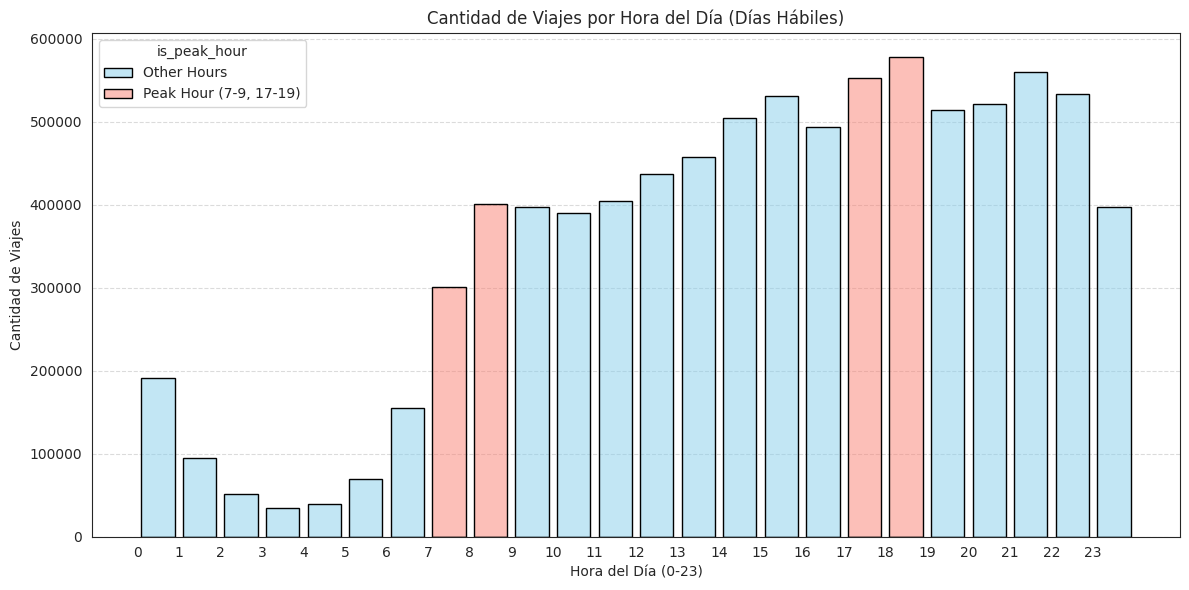

In [ ]:
trips_by_hour_df = df_filtered[df_filtered['pickup_dayofweek'].isin(range(0, 5))]['pickup_hour'].value_counts().sort_index().reset_index()
trips_by_hour_df.columns = ['pickup_hour', 'count']

# Create a new column to categorize peak hours
trips_by_hour_df['is_peak_hour'] = trips_by_hour_df['pickup_hour'].apply(
    lambda h: 'Peak Hour (7-9, 17-19)' if (7 <= h < 9) or (17 <= h < 19) else 'Other Hours'
)

plt.figure(figsize=(12, 6))
sns.histplot(
    data=trips_by_hour_df,
    x='pickup_hour',
    weights='count',
    bins=range(0, 25),
    kde=False,
    hue='is_peak_hour',
    palette={'Peak Hour (7-9, 17-19)': 'salmon', 'Other Hours': 'skyblue'},
    edgecolor='black',
    shrink=0.8 # Adjust bar width slightly to make distinct colors more visible
)

plt.title('Cantidad de Viajes por Hora del Día (Días Hábiles)')
plt.xlabel('Hora del Día (0-23)')
plt.ylabel('Cantidad de Viajes')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

El gráfico anterior nos permite visualizar la distribución de viajes a lo largo del día en dias habiles y verificar la **Hipótesis 1**. Los picos en la mañana (alrededor de las 7-9 am) y en la tarde-noche (alrededor de las 5-7 pm) son evidentes, lo que sugiere una mayor concentración de viajes en los horarios de entrada y salida laboral.

### 11.2 Hipótesis 2 — Precio y distancia



> **Hipótesis 2 — Precio y distancia:** Existe una correlación positiva y fuerte entre la distancia recorrida y el costo total del viaje.



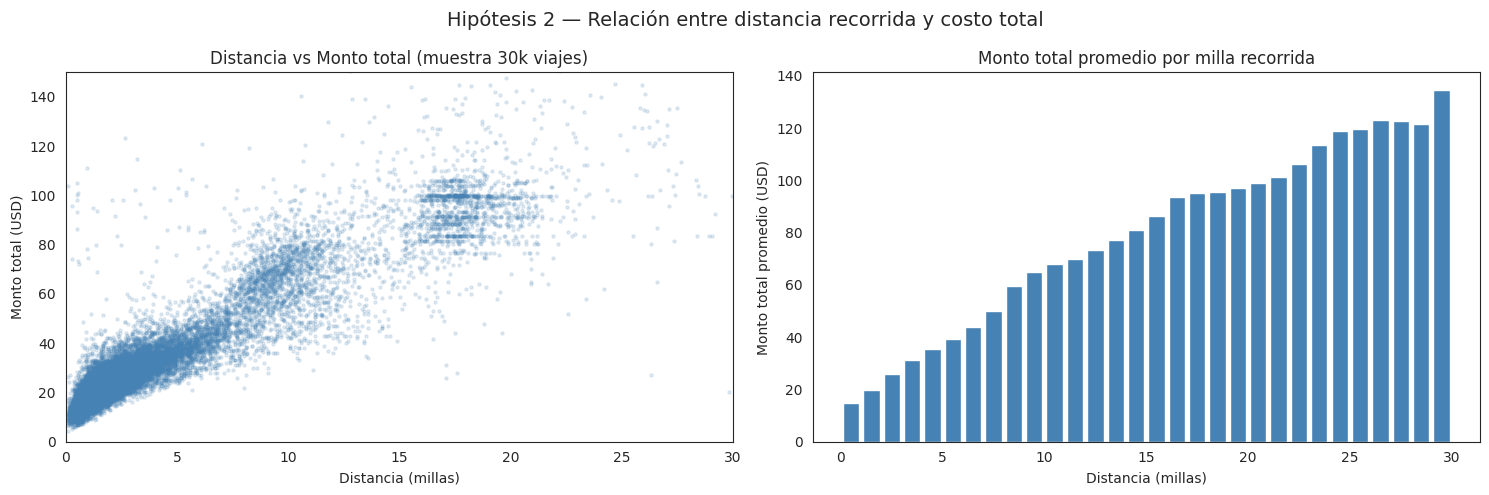

Correlación de Pearson entre trip_distance y total_amount: 0.9328


In [ ]:
df_taxi_h2 = df_filtered[
    (df_filtered["flex_fare_trip_flag"] == 1) &
    (df_filtered["trip_distance"] > 0) &
    (df_filtered["total_amount"] > 0)
].copy()

# Muestra para el scatter (el dataset completo es muy grande para graficar)
sample_h2 = df_taxi_h2.sample(n=30_000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Hipótesis 2 — Relación entre distancia recorrida y costo total", fontsize=14)

# Scatter: distancia vs total_amount
axes[0].scatter(
    sample_h2["trip_distance"],
    sample_h2["total_amount"],
    alpha=0.15, s=5, color="steelblue"
)
axes[0].set_xlabel("Distancia (millas)")
axes[0].set_ylabel("Monto total (USD)")
axes[0].set_title("Distancia vs Monto total (muestra 30k viajes)")
axes[0].set_xlim(0, 30)
axes[0].set_ylim(0, 150)

# Correlación por bins de distancia
df_taxi_h2["dist_bin"] = pd.cut(df_taxi_h2["trip_distance"], bins=range(0, 31), right=False)
corr_by_bin = df_taxi_h2.groupby("dist_bin", observed=True)["total_amount"].mean().reset_index()
corr_by_bin["dist_center"] = corr_by_bin["dist_bin"].apply(lambda x: x.left + 0.5)

axes[1].bar(corr_by_bin["dist_center"], corr_by_bin["total_amount"], width=0.8, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Distancia (millas)")
axes[1].set_ylabel("Monto total promedio (USD)")
axes[1].set_title("Monto total promedio por milla recorrida")

plt.tight_layout()
plt.show()

# Coeficiente de correlación
corr = df_taxi_h2[["trip_distance", "total_amount"]].corr().iloc[0, 1]
print(f"Correlación de Pearson entre trip_distance y total_amount: {corr:.4f}")

del df_taxi_h2, sample_h2

Los resultados obtenidos confirman la hipótesis planteada, evidenciando una correlación positiva y fuerte (r ≈ 0.93) entre la distancia recorrida y el costo total del viaje. Esto indica que, en general, a mayor distancia, mayor es el monto cobrado, lo cual es consistente con la estructura tarifaria del sistema de taxis.

Aunque la relación no es perfectamente lineal, ya que se observa dispersión en los datos para distancias similares, esto implica que la distancia no es el único factor determinante del precio, ya que existen múltiples componentes tarifarios adicionales (recargos, peajes, tarifas fijas, etc.).

Adicionalmente, el análisis por bins de distancia muestra que el costo promedio aumenta de manera aproximadamente monotónica (a medida que aumenta la distancia, el precio generalmente aumenta) con la distancia, reforzando la relación positiva observada en el scatter plot.

Podemos concluir que la distancia es un factor determinante en el costo del viaje, aunque no el único.

### 11.3 Hipótesis 3 - Concentración geográfica



> **Hipótesis 3 — Concentración geográfica:** La mayoría de los viajes inician y terminan en Manhattan, especialmente en zonas céntricas y aeropuertos.



Para darle legilibidad al análisis de la información geográfica, realizamos un `join` con el archivo `taxi_zone_lookup.csv`. Este archivo contiene los nombres de las zonas (`Zone`) y los distritos (`Borough`) correspondientes a cada `LocationID`.

**Propósito:**
*   **Convertir IDs numéricos a nombres:** Las columnas `PULocationID` y `DOLocationID` son identificadores numéricos que por sí solos no brindan información significativa sobre la ubicación. Al unirlos con el archivo de zonas, podemos obtener el `borough` y el `zone_name` (ej. Manhattan, Queens, Times Square, Harlem) de origen y destino de cada viaje.
*   **Facilitar el análisis geográfico:** Esta información es relevante para verificar nuestra hipótesis, permitiéndonos identificar las áreas de mayor actividad de taxis y entender patrones de movimiento en la ciudad.

In [ ]:
zones = pd.read_csv("taxi_zone_lookup.csv")
print("Columnas del archivo de zonas:", zones.columns.tolist())
zones.head(3)

Columnas del archivo de zonas: ['LocationID', 'Borough', 'Zone', 'service_zone']


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone


In [ ]:
zones = zones[["LocationID", "Borough", "Zone"]].rename(columns={
    "Borough": "borough",
    "Zone":    "zone_name"
})

borough_map = zones.set_index("LocationID")["borough"].to_dict()
zone_map = zones.set_index("LocationID")["zone_name"].to_dict()
del zones  # ya no la necesitamos

df_filtered["PU_borough"] = df_filtered["PULocationID"].map(borough_map)
df_filtered["PU_zone"]    = df_filtered["PULocationID"].map(zone_map)
df_filtered["DO_borough"] = df_filtered["DOLocationID"].map(borough_map)
df_filtered["DO_zone"]    = df_filtered["DOLocationID"].map(zone_map)

print(f"Filas con PU_borough nulo: {df_filtered['PU_borough'].isna().sum():,}")
print(f"Filas con DO_borough nulo: {df_filtered['DO_borough'].isna().sum():,}")
print("\nBoroughs de origen:")
print(df_filtered["PU_borough"].value_counts())

Filas con PU_borough nulo: 1,491
Filas con DO_borough nulo: 48,817

Boroughs de origen:
PU_borough
Manhattan        10404143
Queens            1178932
Brooklyn           460211
Bronx               97670
Unknown             19203
Staten Island        1069
EWR                    98
Name: count, dtype: int64


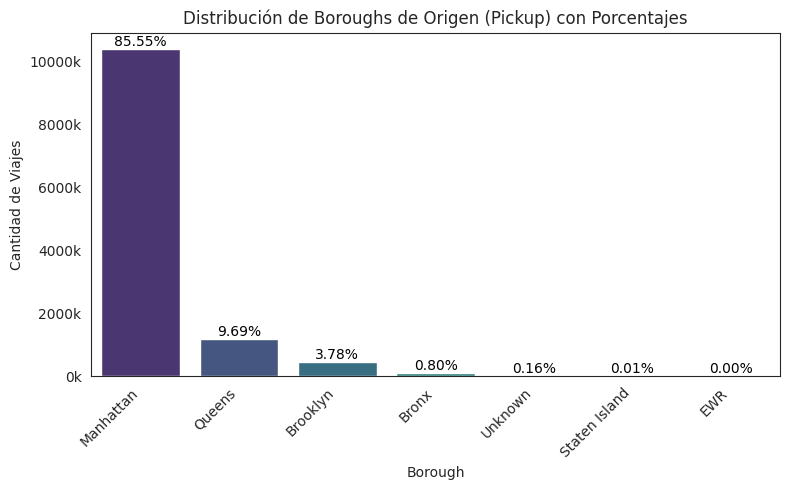

In [ ]:
# Grafica que muestre la distribucion de boroughs

plt.figure(figsize=(8, 5))
borough_counts = df_filtered['PU_borough'].value_counts()
total_trips = borough_counts.sum()

ax = sns.barplot(
    x=borough_counts.index,
    y=borough_counts.values,
    hue=borough_counts.index,
    palette='viridis',
    legend=False
)

# Agrego porcentajes
for p in ax.patches:
    percentage = '{:.2f}%'.format(100 * p.get_height()/total_trips)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10, color='black')

plt.title('Distribución de Boroughs de Origen (Pickup) con Porcentajes')
plt.xlabel('Borough')
plt.ylabel('Cantidad de Viajes')
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
plt.tight_layout()
plt.show()

El join con el archivo de zonas del TLC nos permitió traducir los IDs numéricos de origen y destino a nombres de zonas y boroughs reales.

Los resultados muestran que 1,491 viajes ($0.01\%$) tienen un PULocationIDsin correspondencia en el archivo de zonas, y 48,817 ($0.4\%$) tienen un DOLocationID sin correspondencia.

La distribución por borough de origen confirma la Hipótesis 3: Manhattan concentra el $85\%$ de los viajes, seguido por Queens ($10\%$) impulsado principalmente por los aeropuertos JFK y LaGuardia, y Brooklyn ($4\%$). Bronx y Staten Island tienen participación marginal, lo cual es consistente con la naturaleza del servicio de taxis amarillos que históricamente opera casi exclusivamente en Manhattan e inmediaciones.

## 13. Preguntas adicionales


### 13.1 ¿En qué horarios del día se concentra la mayor cantidad de viajes?

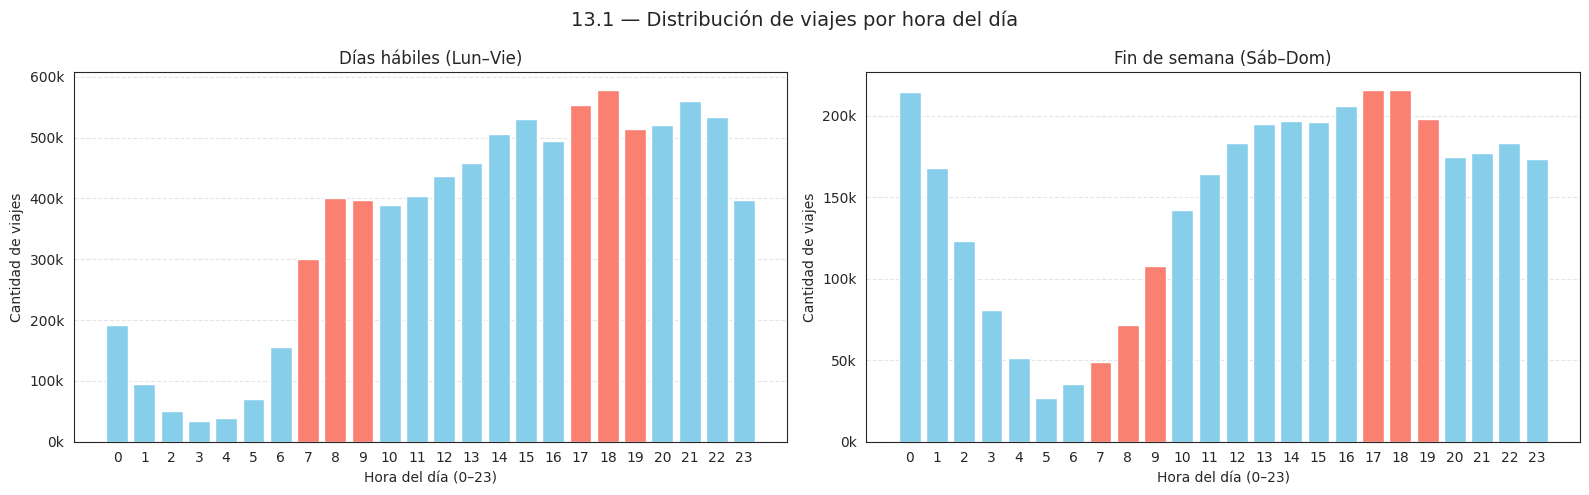

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("13.1 — Distribución de viajes por hora del día", fontsize=14)

for ax, (days, label) in zip(axes, [
    (range(0, 5), "Días hábiles (Lun–Vie)"),
    ([5, 6], "Fin de semana (Sáb–Dom)")
]):
    data = df_filtered[df_filtered["pickup_dayofweek"].isin(days)]["pickup_hour"].value_counts().sort_index()
    peak_mask = data.index.isin(list(range(7, 10)) + list(range(17, 20)))
    colors = ["salmon" if p else "skyblue" for p in peak_mask]
    ax.bar(data.index, data.values, color=colors, edgecolor="white")
    ax.set_title(label)
    ax.set_xlabel("Hora del día (0–23)")
    ax.set_ylabel("Cantidad de viajes")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
    ax.set_xticks(range(0, 24))
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

La distribución de viajes en días hábiles muestra dos picos claramente diferenciados: uno matutino entre las 8 y las 9 hs, y uno más pronunciado entre las 17 y las 19 hs, coherente con los horarios de entrada y salida laboral.

En **días hábiles** el hueco más profundo se produce entre las 3 y las 5 de la madrugada. Los **fines de semana** el patrón es diferente: la actividad nocturna se extiende más, con un pico tardío entre las 21 y las 00 hs, y el pico matinal desaparece.


### 13.2 ¿Cómo se relaciona la distancia del viaje con el costo total?


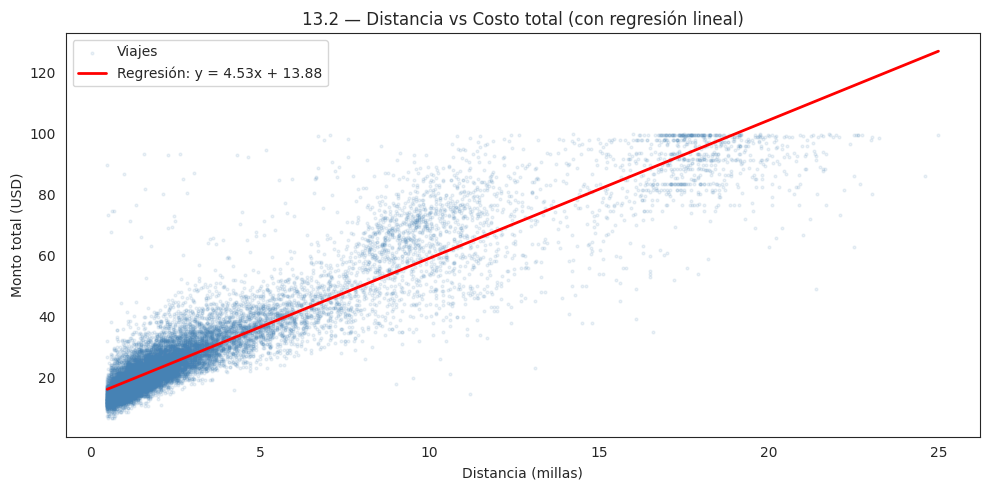

Por cada milla adicional, el monto total aumenta en promedio $4.53 USD


In [ ]:
# Esta pregunta ya fue respondida en la hipótesis 2 con mayor detalle.
# Acá agregamos una regresión lineal simple para cuantificar la relación.

from numpy.polynomial.polynomial import polyfit

df_reg = df_filtered[
    (df_filtered["flex_fare_trip_flag"] == 1) &
    (df_filtered["trip_distance"].between(0.5, 25)) &
    (df_filtered["total_amount"].between(3, 100))
].sample(20_000, random_state=42)

coef = np.polyfit(df_reg["trip_distance"], df_reg["total_amount"], 1)
x_line = np.linspace(0.5, 25, 100)
y_line = np.polyval(coef, x_line)

plt.figure(figsize=(10, 5))
plt.scatter(df_reg["trip_distance"], df_reg["total_amount"], alpha=0.1, s=4, color="steelblue", label="Viajes")
plt.plot(x_line, y_line, color="red", linewidth=2, label=f"Regresión: y = {coef[0]:.2f}x + {coef[1]:.2f}")
plt.xlabel("Distancia (millas)")
plt.ylabel("Monto total (USD)")
plt.title("13.2 — Distancia vs Costo total (con regresión lineal)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Por cada milla adicional, el monto total aumenta en promedio ${coef[0]:.2f} USD")

del df_reg

La regresión lineal entre trip_distance y total_amount arroja un coeficiente de correlación de Pearson de ~0.93, confirmando la hipótesis 2. Por cada milla adicional recorrida, el monto total aumenta en promedio $4.53 USD. La dispersión se incrementa para viajes largos, lo que puede deberse a peajes, recargos de aeropuerto u otros factores que no dependen directamente de la distancia.

### 13.3 ¿Cómo varía el porcentaje de propina (sin incluir pagos en efectivo) según el monto del viaje?


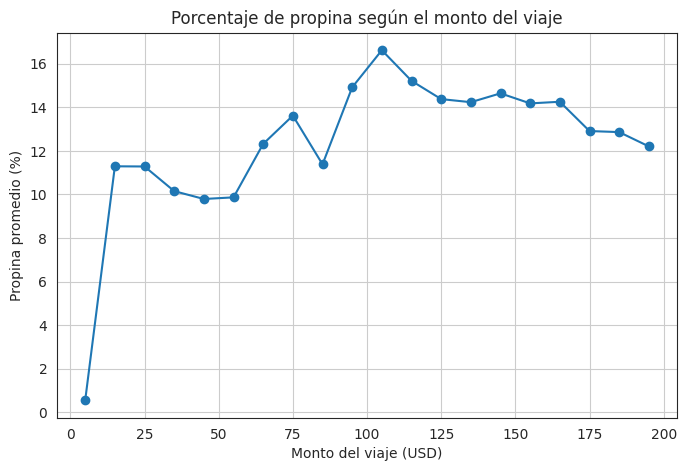

In [ ]:
df_tip = df_filtered.copy()

# Excluir efectivo (no hay propina registrada)
df_tip = df_tip[df_tip["payment_type"] != 2]

df_tip = df_tip[df_tip["total_amount"] > 0]

df_tip["tip_pct"] = df_tip["tip_amount"] / df_tip["total_amount"] * 100

df_tip["fare_bin"] = pd.cut(df_tip["total_amount"], bins=range(0, 201, 10))

tip_by_bin = df_tip.groupby("fare_bin", observed=True)["tip_pct"].mean().reset_index()

tip_by_bin["bin_center"] = tip_by_bin["fare_bin"].apply(lambda x: x.left + 5)


plt.figure(figsize=(8,5))
plt.plot(tip_by_bin["bin_center"], tip_by_bin["tip_pct"], marker="o")

plt.xlabel("Monto del viaje (USD)")
plt.ylabel("Propina promedio (%)")
plt.title("Porcentaje de propina según el monto del viaje")

plt.grid(True)
plt.show()

Se observa que el porcentaje de propina presenta mayor variabilidad en viajes de bajo monto, lo cual puede explicarse por la menor cantidad de observaciones en estos rangos y la mayor sensibilidad a valores extremos.

A partir de montos intermedios, el comportamiento se vuelve más estable, mostrando una tendencia creciente hasta aproximadamente los 100 USD, seguida de una leve disminución en viajes de mayor costo.

### 13.4 ¿Qué zonas concentran la mayor cantidad de viajes?

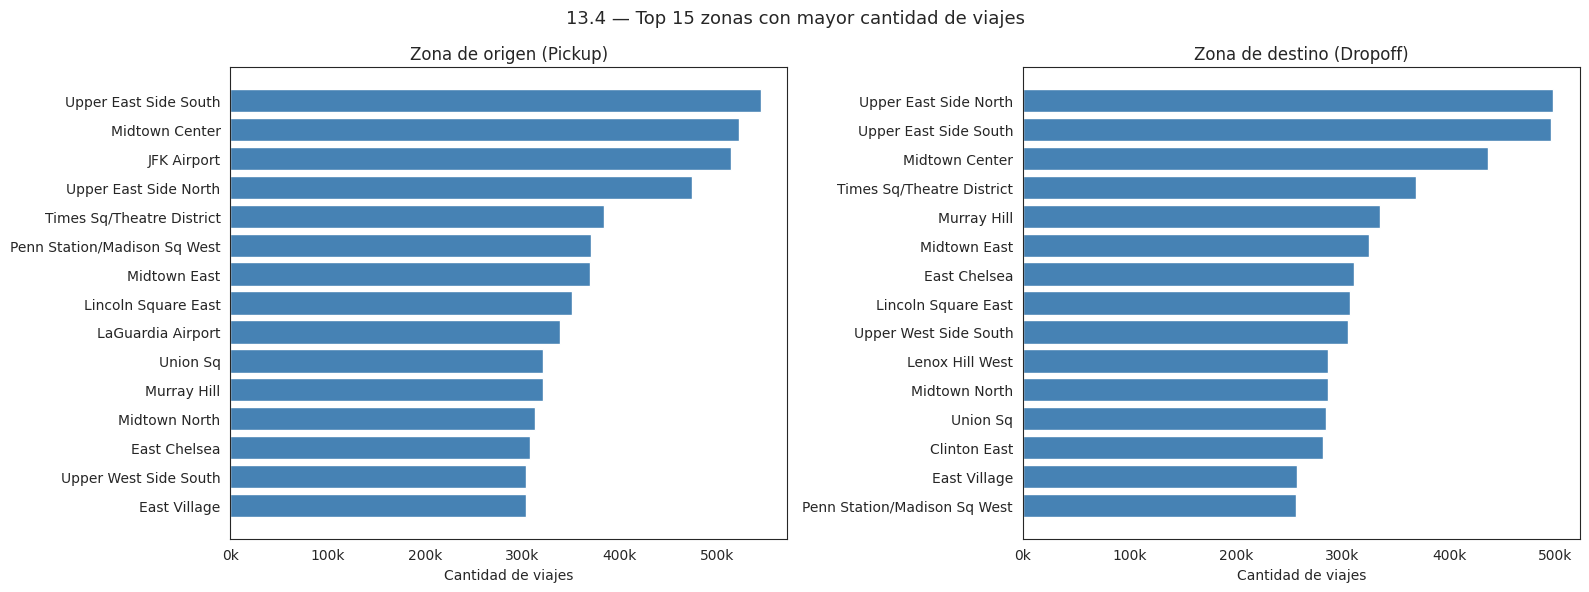

In [ ]:
top_pu_zones = df_filtered["PU_zone"].value_counts().head(15).reset_index()
top_pu_zones.columns = ["zona", "viajes"]

# Top 15 zonas de dropoff
top_do_zones = df_filtered["DO_zone"].value_counts().head(15).reset_index()
top_do_zones.columns = ["zona", "viajes"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("13.4 — Top 15 zonas con mayor cantidad de viajes", fontsize=13)

for ax, data, title in zip(axes,
    [top_pu_zones, top_do_zones],
    ["Zona de origen (Pickup)", "Zona de destino (Dropoff)"]):
    ax.barh(data["zona"][::-1], data["viajes"][::-1], color="steelblue", edgecolor="white")
    ax.set_xlabel("Cantidad de viajes")
    ax.set_title(title)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))

plt.tight_layout()
plt.show()


Las zonas con mayor volumen de viajes de origen son consistentes con la hipótesis 3: Midtown Center, Upper East Side y Penn Station/Madison Sq West encabezan el ranking de pickups. En los destinos, el patrón es similar aunque aparecen con mayor peso las zonas residenciales del Upper West Side. JFK y LaGuardia Airport aparecen en el top 15 en ambos casos, reflejando la fuerte demanda aeroportuaria.

### 13.5 ¿Cómo cambia el precio por milla según el horario del día? ¿Viaja mas o menos gente en esos horarios?

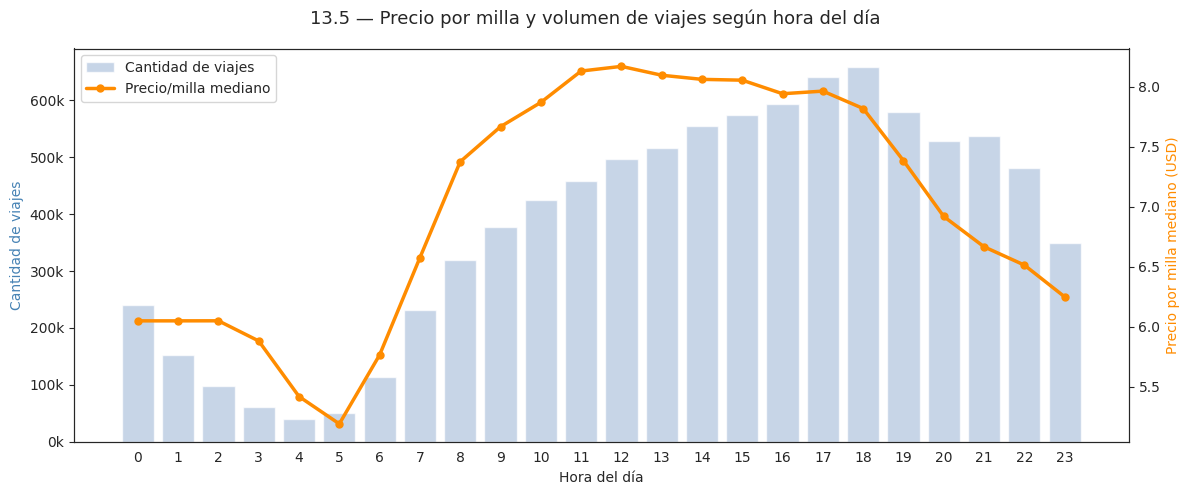

In [ ]:
df_fpm = df_filtered[
    (df_filtered["flex_fare_trip_flag"] == 1) &
    (df_filtered["fare_per_mile"].notna()) &
    (df_filtered["fare_per_mile"].between(1, 30))
].copy()

fpm_by_hour = df_fpm.groupby("pickup_hour").agg(
    fare_per_mile_med=("fare_per_mile", "median"),
    viajes=("fare_per_mile", "count")
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
fig.suptitle("13.5 — Precio por milla y volumen de viajes según hora del día", fontsize=13)

color1, color2 = "steelblue", "darkorange"
ax2 = ax1.twinx()

ax1.bar(fpm_by_hour["pickup_hour"], fpm_by_hour["viajes"], color="lightsteelblue",
        alpha=0.7, label="Cantidad de viajes", zorder=1)
ax2.plot(fpm_by_hour["pickup_hour"], fpm_by_hour["fare_per_mile_med"],
         color=color2, linewidth=2.5, marker="o", markersize=5, label="Precio/milla mediano", zorder=2)

ax1.set_xlabel("Hora del día")
ax1.set_ylabel("Cantidad de viajes", color="steelblue")
ax2.set_ylabel("Precio por milla mediano (USD)", color=color2)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
ax1.set_xticks(range(0, 24))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

del df_fpm

El precio por milla muestra variación horaria notable: es más alto en horas de madrugada (0–5 hs), cuando el volumen es bajo pero los viajes son más largos o hacia zonas con recargo. Durante el pico matinal (8–9 hs), el precio por milla cae a pesar del alto volumen, posiblemente porque los viajes son más cortos y directos. La noche (18–22 hs) muestra un leve repunte del precio por milla coincidente con mayor congestión.


### 13.6 ¿Cuánto del costo del viaje corresponde a impuestos, propina, fees y recargos?
Solo valido para analizar viajes por taximetro ya que en los viajes de tipo Flex Fare no se cargan los montos individuales.

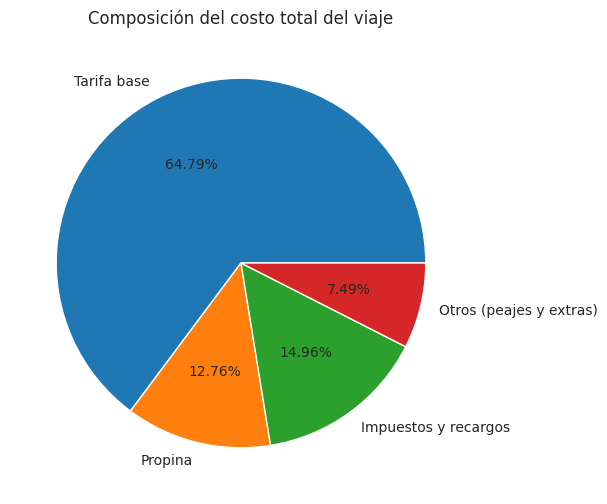

In [ ]:
mask = df_filtered["flex_fare_trip_flag"] == 1

df_tmp = df_filtered.loc[mask]

total_general = df_tmp["total_amount"].sum()

totales = {
    "Tarifa base": df_tmp["fare_amount"].sum(),
    "Propina": df_tmp["tip_amount"].sum(),
    "Impuestos y recargos": (
        df_tmp["mta_tax"].fillna(0).sum() +
        df_tmp["improvement_surcharge"].fillna(0).sum() +
        df_tmp["congestion_surcharge"].fillna(0).sum() +
        df_tmp["cbd_congestion_fee"].fillna(0).sum() +
        df_tmp["Airport_fee"].fillna(0).sum()
    ),
    "Otros (peajes y extras)": (
        df_tmp["tolls_amount"].fillna(0).sum() +
        df_tmp["extra"].fillna(0).sum()
    ),
}

proporciones = {k: v / total_general * 100 for k, v in totales.items()}

plt.figure(figsize=(6,6))
plt.pie(proporciones.values(), labels=proporciones.keys(), autopct='%1.2f%%')
plt.title("Composición del costo total del viaje")
plt.show()


Para el análisis de la composición del costo del viaje, se agruparon los componentes en categorías conceptualmente consistentes. En particular, se consideraron como impuestos y recargos aquellos valores fijos o regulados por la normativa (MTA tax, improvement surcharge, congestion surcharge y CBD congestion fee).

Por otro lado, los peajes (`tolls_amount`) y recargos adicionales (`extra`) se agruparon como "otros costos", ya que dependen de las características específicas del viaje y no constituyen impuestos directos.



### 13.7 ¿El origen/destino influyen en la cantidad de propina recibida?

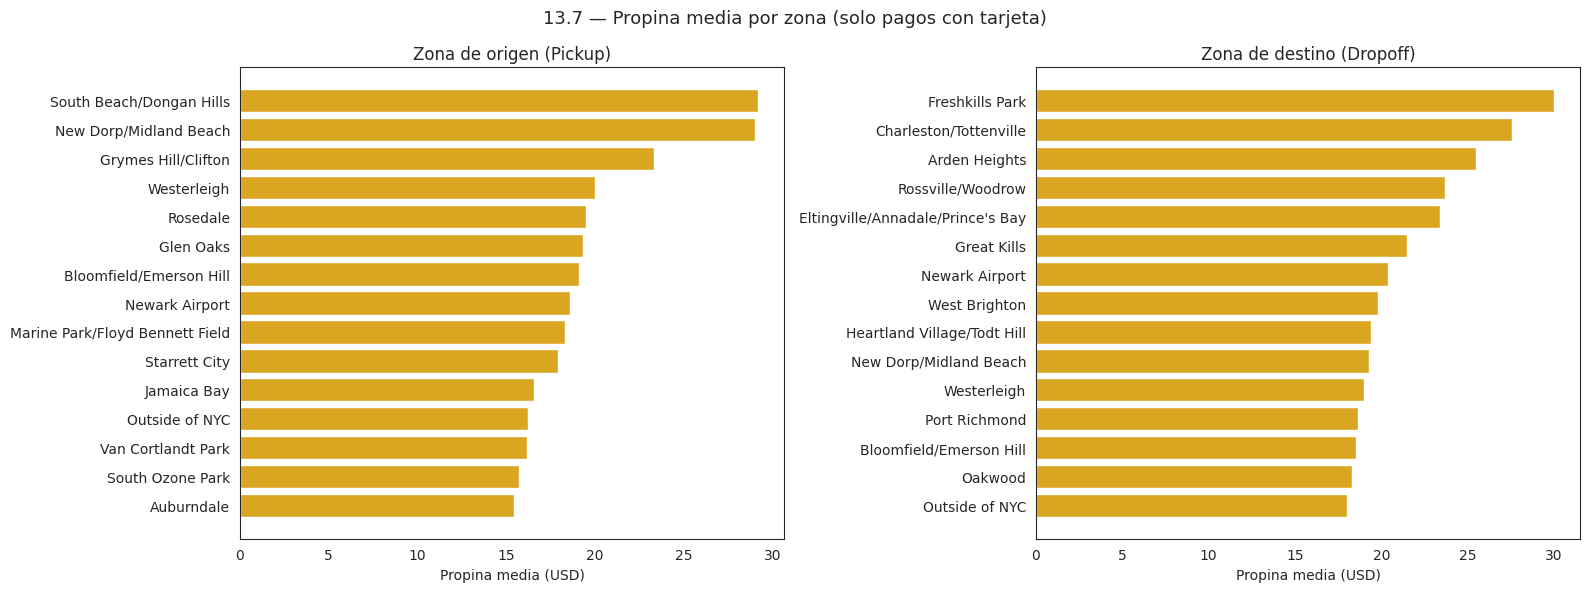

In [ ]:
# Propina media por zona de origen y destino (solo pagos con tarjeta)
mask_tip = (df_filtered["payment_type"] == 1) & (df_filtered["tip_amount"] > 0)

top_pu_tip = (df_filtered.loc[mask_tip]
              .groupby("PU_zone")["tip_amount"]
              .mean().sort_values(ascending=False).head(15).reset_index())
top_pu_tip.columns = ["zona", "propina_media"]

top_do_tip = (df_filtered.loc[mask_tip]
              .groupby("DO_zone")["tip_amount"]
              .mean().sort_values(ascending=False).head(15).reset_index())
top_do_tip.columns = ["zona", "propina_media"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("13.7 — Propina media por zona (solo pagos con tarjeta)", fontsize=13)

for ax, data, title in zip(axes,
    [top_pu_tip, top_do_tip],
    ["Zona de origen (Pickup)", "Zona de destino (Dropoff)"]):
    ax.barh(data["zona"][::-1], data["propina_media"][::-1], color="goldenrod", edgecolor="white")
    ax.set_xlabel("Propina media (USD)")
    ax.set_title(title)

plt.tight_layout()
plt.show()

Las zonas de **aeropuertos** (JFK, LaGuardia, Newark) y de **alto poder adquisitivo** (Upper East Side, Midtown, Financial District) encabezan el ranking de propinas tanto en orígenes como en destinos.

Esto indica que el comportamiento de propinas está fuertemente determinado por el perfil socioeconómico del pasajero y el tipo de viaje. Los viajes hacia/desde aeropuertos y zonas premium generan propinas significativamente mayores que los viajes urbanos ordinarios. Las zonas de destino con mayor propina coinciden en gran medida con las de origen, lo que sugiere que los viajes premium son bidireccionales.

> **Nota metodológica:** solo se consideran pagos con tarjeta (~70% de los viajes), ya que las propinas en efectivo no quedan registradas en el dataset. Esto introduce un sesgo de selección a tener en cuenta al interpretar los resultados.

### 13.8 ¿Cómo se distribuyen las duraciones de los viajes y cómo varían por día de la semana o franja horaria?

/tmp/ipykernel_64301/174615466.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(orden_franjas, rotation=15, ha="right")


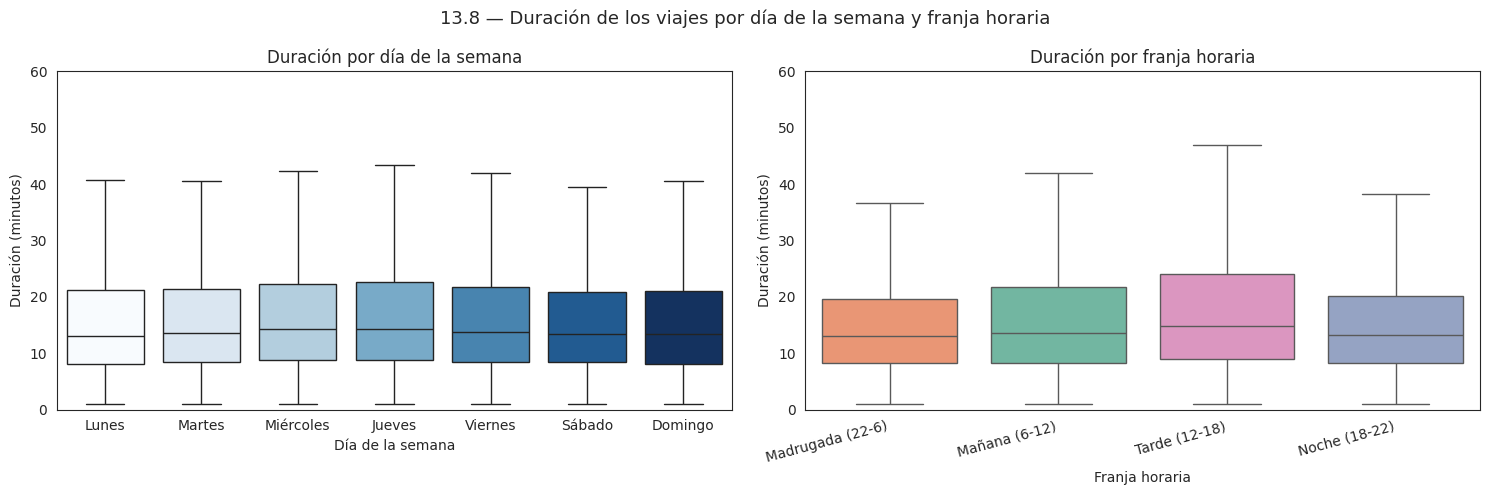

40549

In [ ]:
# Duración de viajes por día de la semana y franja horaria
dias_map = {0: "Lunes", 1: "Martes", 2: "Miércoles", 3: "Jueves",
            4: "Viernes", 5: "Sábado", 6: "Domingo"}

# Samplear para no reventar la RAM — los cuartiles son estables con 200k filas
df_dur = df_filtered[["pickup_dayofweek", "franja_horaria", "trip_duration_min"]].sample(
    n=200_000, random_state=42
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("13.8 — Duración de los viajes por día de la semana y franja horaria", fontsize=13)

sns.boxplot(
    data=df_dur,
    x="pickup_dayofweek",
    y="trip_duration_min",
    hue="pickup_dayofweek",
    legend=False,
    ax=axes[0],
    showfliers=False,
    palette="Blues"
)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels([dias_map[i] for i in range(7)])
axes[0].set_xlabel("Día de la semana")
axes[0].set_ylabel("Duración (minutos)")
axes[0].set_title("Duración por día de la semana")
axes[0].set_ylim(0, 60)

orden_franjas = ["Madrugada (22-6)", "Mañana (6-12)", "Tarde (12-18)", "Noche (18-22)"]
sns.boxplot(
    data=df_dur,
    x="franja_horaria",
    y="trip_duration_min",
    hue="franja_horaria",
    legend=False,
    order=orden_franjas,
    ax=axes[1],
    showfliers=False,
    palette="Set2"
)
axes[1].set_xticklabels(orden_franjas, rotation=15, ha="right")
axes[1].set_xlabel("Franja horaria")
axes[1].set_ylabel("Duración (minutos)")
axes[1].set_title("Duración por franja horaria")
axes[1].set_ylim(0, 60)

plt.tight_layout()
plt.show()

del df_dur
gc.collect()

La duración media de los viajes es de aproximadamente **14 minutos**, con una distribución asimétrica a la derecha típica de este tipo de datos.

**Por día de la semana:** los viernes y sábados muestran la mayor duración mediana, asociada a mayor congestión vespertina/nocturna y trayectos de entretenimiento más largos. Los días hábiles de mitad de semana presentan duraciones más uniformes.

**Por franja horaria:** la franja Tarde (12–18 hs) y Noche (18–22 hs) concentran los viajes más largos, en línea con la congestión en Manhattan durante esas horas. La Madrugada tiene viajes más rápidos — la ausencia de tráfico compensa los destinos más lejanos. La franja Mañana (6–12 hs) presenta la menor dispersión, indicando mayor predictibilidad en duración.

### 13.9 ¿Hay zonas con poca cobertura de red en la ciudad?

Queremos analizar si la columna "store_and_fwd_flag" que originalmente se usa para determinar que la información no pudo ser enviada en su momento puede reflejar que hay zonas claras donde falla la cobertura de red, para ello utilizaremos la información de geoposición provista y dibujaremos en un mapa las zonas donde se registraron más de estos problemas:

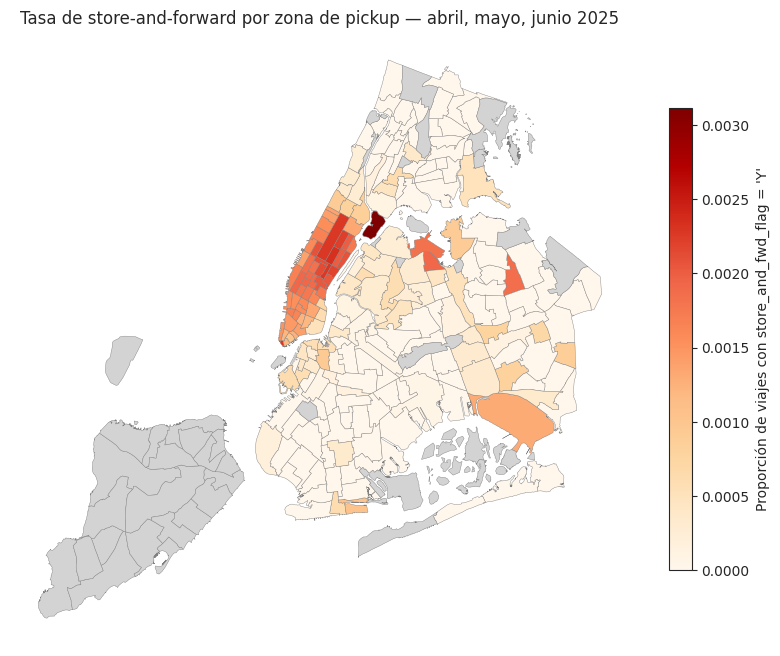

In [ ]:
import geopandas as gpd

!unzip -o -q taxi_zones.zip

zones = gpd.read_file("taxi_zones.shp")

total = df_filtered.groupby("PULocationID").size().rename("total")
fwd   = df_filtered[df_filtered["store_and_fwd_flag"] == "Y"].groupby("PULocationID").size().rename("fwd")

stats = pd.concat([total, fwd], axis=1).fillna(0)
stats["ratio"] = stats["fwd"] / stats["total"]

stats.loc[stats["total"] < 500, "ratio"] = None

zones_plot = zones.merge(stats, left_on="LocationID", right_index=True, how="left")

fig, ax = plt.subplots(figsize=(10, 10))
zones_plot.plot(
    column="ratio",
    cmap="OrRd",
    legend=True,
    ax=ax,
    edgecolor="gray",
    linewidth=0.3,
    missing_kwds={"color": "lightgray"},
    legend_kwds={"label": "Proporción de viajes con store_and_fwd_flag = 'Y'",
                 "shrink": 0.6}
)
ax.set_title("Tasa de store-and-forward por zona de pickup — abril, mayo, junio 2025")
ax.set_axis_off()
plt.show()

El gráfico permite notar varias cosas interesantes:
- Governor's Island tiene muy mala cobertura por razones obvias.
- Roosevelt Island al este de Manhattan es también otra zona con mala cobertura por las mismas razones.
- En la zona del aeropuerto JFK también se registran muchos problemas de conectividad, probablemente se deba a la lejanía con las antenas de celular que podrían interferir con el control aéreo.
- Lo mismo sucede con el aeropuerto de La Guardia.
- Manhattan concentra zonas con mala cobertura, al ser una de las zonas más densamente pobladas probablemente la red se encuentre saturada, de igual modo, los altos rascacielos pueden jugar un papel en los problemas que puede tener la señal:
https://www.timeout.com/newyork/blog/the-worst-cell-reception-in-new-york-is-in-this-manhattan-neighborhood-090716
https://esim.holafly.com/research/us-cities-with-most-cell-signal-dead-zone/

En la fuente citada se lee lo siguiente que lo refleja de forma cabal:

*Our final map shows each state’s **worst ZIP code for cell signal dead zones. New York’s is Manhattan 10018, with 808 complaints per million inhabitants. One survey found that around 60% of Manhattan residents frequently suffer dropped calls**. “It shouldn’t be like that in 2024. The whole world has stepped up, and Manhattan hasn’t, I don’t really understand,” Manhattan dogwalker Sonya Burns told the New York Post*

# 14. Conclusión general


Este análisis exploratorio de los datos de viajes de Yellow Cab de NYC para abril, mayo y junio de 2025 reveló patrones significativos y características clave del servicio.

* **Calidad y Preparación de Datos:**

Se identificó una gran cantidad de datos (`12.8M` registros), con variables de diversos tipos.

La gestión de valores nulos fue crucial, especialmente para las columnas `passenger_count`, `RatecodeID`, `store_and_fwd_flag`, `congestion_surcharge` y `Airport_fee`, que mostraron una correlación perfecta de ausencia de datos. Esto se atribuyó a viajes tipo 'Flex Fare', que manejan una estructura tarifaria diferente. Se creó una bandera `flex_fare_trip_flag` para diferenciar estos viajes.

El filtrado de outliers se aplicó para eliminar registros anómalos relacionados con la duración del viaje, la distancia, los montos y el número de pasajeros, asegurando la consistencia de los datos.

* **Patrones de Viaje y Horarios:**

Se confirmó la hipótesis de que la mayor concentración de viajes ocurre en las horas pico laborales (7-9 AM y 5-7 PM) durante los días hábiles. Los fines de semana muestran un patrón diferente, con mayor actividad nocturna.

Además, la duración promedio de los viajes varía según el día de la semana y la franja horaria, siendo la franja Tarde (12–18 hs) y Noche (18–22 hs) las que concentran los viajes de mayor duración, con los viernes y sábados mostrando las medianas más altas por día de la semana, mientras que los picos de la mañana y la tarde en días hábiles se caracterizan por viajes más cortos y directos.

* **Relación entre Costo y Distancia:**

Existe una correlación positiva y fuerte (coeficiente de Pearson ≈ 0.93) entre la distancia recorrida (`trip_distance`) y el costo total del viaje (`total_amount`). Por cada milla adicional, el monto total aumenta en promedio $4.53 USD. Esto remarca la relevancia de la distancia como principal motor del costo, aunque no el único.

* **Aspectos Geográficos:**

La vasta mayoría de los viajes (85%) se originan y/o terminan en Manhattan, con Queens (principalmente aeropuertos JFK y LaGuardia) como el segundo borough más relevante. Esto valida la hipótesis de una fuerte concentración geográfica en las zonas céntricas y aeroportuarias.

Midtown Center, Upper East Side y Penn Station/Madison Sq West son consistentemente las zonas de mayor actividad (pickup y dropoff).

El análisis de la `store_and_fwd_flag` reveló zonas con problemas de conectividad (ej. Governor's Island, Roosevelt Island y áreas densas de Manhattan), indicando posibles limitaciones de infraestructura de red en ciertas ubicaciones.

* **Componentes del Costo y Propinas:**

La tarifa base (`fare_amount`) constituye la mayor parte del costo total (aproximadamente 64.79%), seguida por impuestos y recargos (14.96%), propinas (12.76%) y otros costos (7.49%).

El análisis por hora del día muestra que la Madrugada (0–5 hs) presenta el precio por milla más alto a pesar del bajo volumen, dado que los viajes son más fluidos por la ausencia de tráfico pero tienden hacia destinos más alejados o con recargos.

El porcentaje de propina (para pagos no en efectivo) muestra una mayor variabilidad en viajes de bajo monto, estabilizándose y mostrando una ligera tendencia al aumento hasta los 100 USD, para luego disminuir levemente en viajes de mayor valor.

* **Zonas con poca cobertura de red:**

De acuerdo al análisis de los datos y a la proyección sobre el mapa de New York podemos concluir que las zonas con problemas de conectividad están claramente delimitadas y no son aleatorias. Es especialmente llamativo el caso de Manhattan, una de las zonas más caras del mundo, presente tantos problemas de conectividad, evidenciando faltas de inversión o planeamiento. Enfocándonos puntualmente en el dataset tratado, ya que la gran mayoría de los viajes son también en esa zona, sería conveniente que los taxis busquen otra estrategia para enviar los datos.